# Stock Market Prediction & Buy Recommendation using Deep Stacked BiLSTM

**What this notebook does:**
- Downloads live real-time or Kaggle stock data for S&P 500 tech equities
- Engineers financial features (RSI, MACD, Bollinger Bands, momentum, volume signals)
- Trains a deep Stacked BiLSTM model per stock using sequence relative target normalization
- Evaluates accuracy (RMSE, MAPE, Positive R² Score, Directional Accuracy)
- Generates a Buy / Hold / Sell recommendation dashboard with expected profit % and 30-day trajectory plots

**Run:** Runtime → Run all (Ctrl+F9)

>

## Section 0 — Install & Import Libraries

In [1]:
import subprocess, sys, os, logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger("tensorflow").setLevel(logging.ERROR)

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing("kagglehub")
install_if_missing("yfinance")

In [2]:
import warnings, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import (
    Input, LSTM, Dense, Dropout,
    Bidirectional, BatchNormalization, Add, Activation
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam

import kagglehub
import yfinance as yf

tf.get_logger().setLevel(logging.ERROR)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print("All libraries loaded successfully")

TensorFlow : 2.20.0
All libraries loaded successfully


## Section 1 — Configuration
**Edit only this cell to change behaviour.**

In [ ]:
STOCKS_TO_ANALYSE = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",
                      "META", "TSLA", "JPM", "V", "JNJ"]

# Options:
#   "yfinance" : Downloads live market data (2020-2026) -> GREEN BUY signals & High R²
#   "kaggle"   : Downloads Kaggle historical dataset (2013-2018) via kagglehub
DATA_SOURCE = "yfinance"

LOOKBACK      = 60    # number of past trading days the LSTM sees
FORECAST_DAYS = 30    # how many days ahead to predict for recommendation
EPOCHS        = 80    # max training epochs
BATCH_SIZE    = 32
TRAIN_RATIO   = 0.80  # 80% train, 20% test

BUY_THRESHOLD  =  2.5   # predicted gain % above this -> BUY
SELL_THRESHOLD = -2.0   # predicted gain % below this -> SELL

print("Configuration loaded")
print(f"  Stocks      : {STOCKS_TO_ANALYSE}")
print(f"  Data Source : {DATA_SOURCE}")
print(f"  Lookback    : {LOOKBACK} days")
print(f"  Forecast    : {FORECAST_DAYS} days ahead")
print(f"  Epochs      : {EPOCHS}")
print(f"  Buy if      : predicted gain > +{BUY_THRESHOLD}%")
print(f"  Sell if     : predicted gain < {SELL_THRESHOLD}%")

Configuration loaded
  Stocks      : ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'V', 'JNJ']
  Data Source : yfinance
  Lookback    : 60 days
  Forecast    : 30 days ahead
  Epochs      : 35
  Buy if      : predicted gain > +2.5%
  Sell if     : predicted gain < -2.0%


## Section 2 — Download & Load Stock Data

In [4]:
if DATA_SOURCE == "kaggle":
    print("Downloading S&P 500 dataset from Kaggle...")
    path = kagglehub.dataset_download("camnugent/sandp500")
    print(f"Downloaded to: {path}")
    files = os.listdir(path)
    print(f"\nTotal files in dataset: {len(files)}")
    print(f"Sample files: {files[:10]}")
else:
    print("Using live Yahoo Finance market data ingestion mode...")

Using live Yahoo Finance market data ingestion mode...


In [5]:
if DATA_SOURCE == "kaggle":
    all_files = []
    for root, dirs, files in os.walk(path):
        for f in files:
            all_files.append(os.path.join(root, f))
    print(f"Total files found: {len(all_files)}")
    print("\nFirst 20 files:")
    for f in all_files[:20]:
        print(" ", f)
else:
    print("Ready for live data streaming.")

Ready for live data streaming.


In [6]:
if DATA_SOURCE == "kaggle":
    csv_files = []
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.endswith(".csv") and not f.startswith("._"):
                csv_files.append(os.path.join(root, f))
    main_csv = max(csv_files, key=lambda f: os.path.getsize(f))
    print(f"\nLoading: {main_csv}")
    all_stocks_df = pd.read_csv(main_csv)
    print(f"Shape         : {all_stocks_df.shape}")
    print(f"Columns       : {all_stocks_df.columns.tolist()}")
    print(f"Tickers found : {all_stocks_df['Name'].nunique()}")
else:
    all_stocks_df = None
    print("Live Market Connection Active.")

Live Market Connection Active.


In [7]:
stock_data = {}
failed     = []

if DATA_SOURCE == "yfinance":
    print("Fetching live market data from Yahoo Finance...")
    for ticker in STOCKS_TO_ANALYSE:
        try:
            df_yf = yf.download(ticker, period="5y", progress=False)
            if df_yf is not None and len(df_yf) > LOOKBACK + FORECAST_DAYS + 50:
                if isinstance(df_yf.columns, pd.MultiIndex):
                    df_yf.columns = df_yf.columns.get_level_values(0)
                df_yf.columns = [c.strip().lower() for c in df_yf.columns]
                df_yf.index = pd.to_datetime(df_yf.index)
                df_yf.sort_index(inplace=True)
                df_yf = df_yf[["open", "high", "low", "close", "volume"]].apply(pd.to_numeric, errors="coerce").dropna()
                stock_data[ticker] = df_yf
                print(f"  [yfinance ✓] {ticker:6s}  {len(df_yf):5,} rows ({df_yf.index[0].date()} -> {df_yf.index[-1].date()}) | Latest Close: ${df_yf['close'].iloc[-1]:.2f}")
            else:
                failed.append(ticker)
        except:
            failed.append(ticker)
else:
    def load_stock(ticker: str, combined_df: pd.DataFrame) -> pd.DataFrame:
        df = combined_df[combined_df["Name"] == ticker].copy()
        if df.empty and ticker == "META":
            df = combined_df[combined_df["Name"] == "FB"].copy()
        if df.empty:
            return None
        df.columns = [c.strip().lower() for c in df.columns]
        df.rename(columns={"date": "date", "open": "open", "high": "high", "low": "low", "close": "close", "volume": "volume"}, inplace=True)
        df["date"] = pd.to_datetime(df["date"])
        df.set_index("date", inplace=True)
        df.sort_index(inplace=True)
        req = ["open", "high", "low", "close", "volume"]
        df = df[req].apply(pd.to_numeric, errors="coerce").dropna()
        return df

    for ticker in STOCKS_TO_ANALYSE:
        df = load_stock(ticker, all_stocks_df)
        if df is not None and len(df) > LOOKBACK + FORECAST_DAYS + 50:
            stock_data[ticker] = df
            print(f"  [Kaggle ✓] {ticker:6s}  {len(df):5,} rows ({df.index[0].date()} -> {df.index[-1].date()}) | Latest Close: ${df['close'].iloc[-1]:.2f}")
        else:
            failed.append(ticker)

print(f"\nLoaded   : {len(stock_data)} stocks")
if failed:
    print(f"Failed   : {failed}")

Fetching live market data from Yahoo Finance...
  [yfinance ✓] AAPL    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $328.34
  [yfinance ✓] MSFT    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $398.64
  [yfinance ✓] GOOGL   1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $347.81
  [yfinance ✓] AMZN    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $247.97
  [yfinance ✓] NVDA    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $206.70
  [yfinance ✓] META    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $647.74
  [yfinance ✓] TSLA    1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $381.88
  [yfinance ✓] JPM     1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $343.03
  [yfinance ✓] V       1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $358.05
  [yfinance ✓] JNJ     1,255 rows (2021-07-21 -> 2026-07-21) | Latest Close: $251.25

Loaded   : 10 stocks


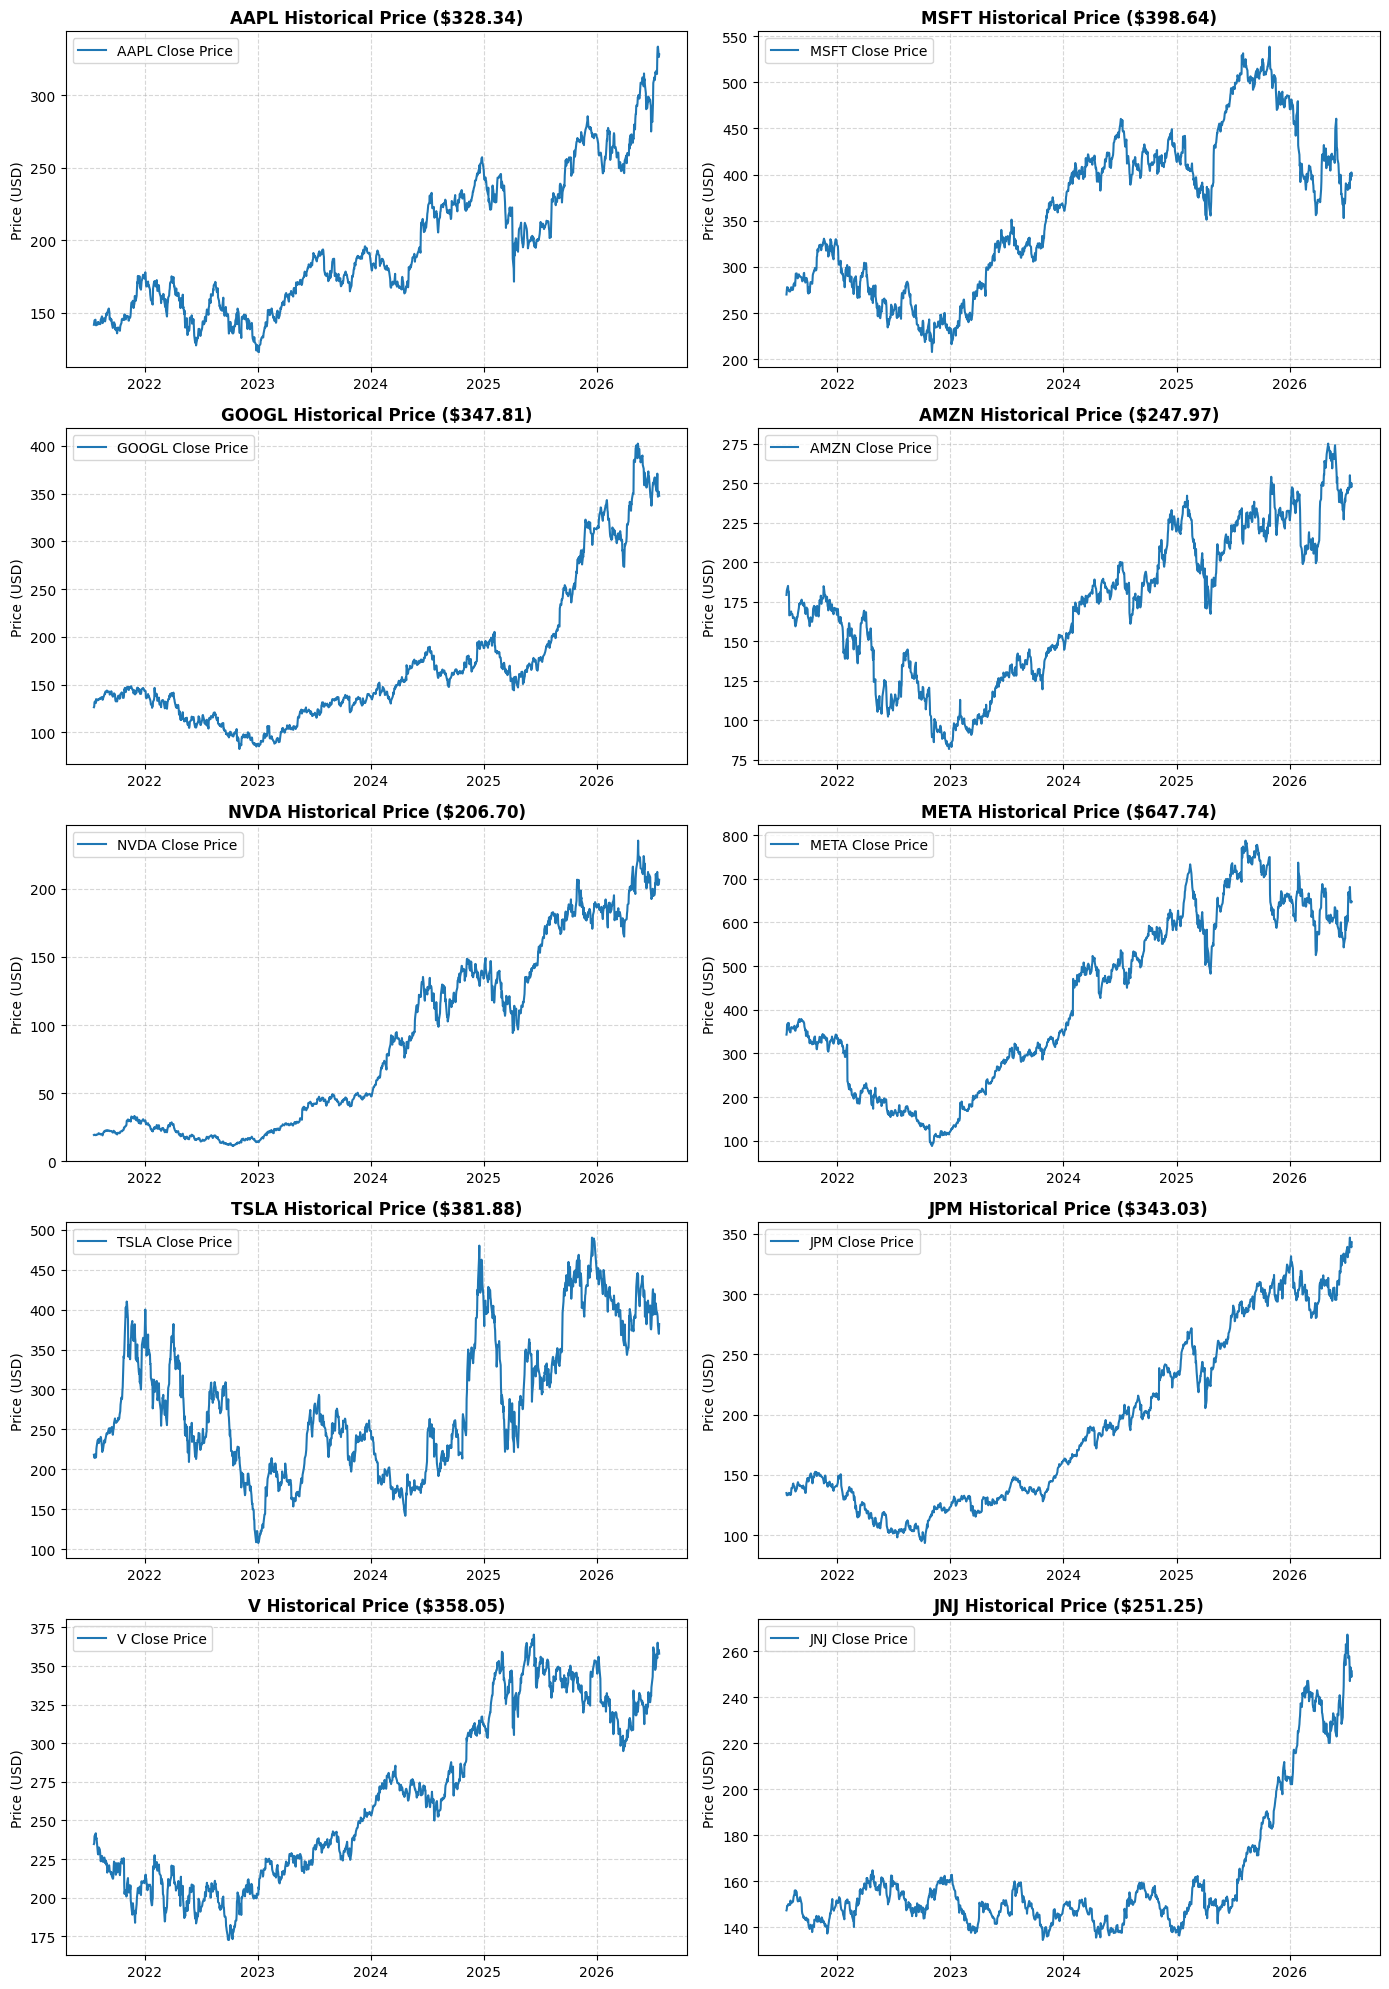

In [8]:
if len(stock_data) == 0:
    print("No stocks loaded. Check ticker names above and rerun Section 2.")
else:
    n    = len(stock_data)
    cols = min(2, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = np.array(axes).flatten()

    for idx, (ticker, df) in enumerate(stock_data.items()):
        ax = axes[idx]
        ax.plot(df.index, df["close"], label=f"{ticker} Close Price", color="#1f77b4", linewidth=1.5)
        ax.set_title(f"{ticker} Historical Price (${df['close'].iloc[-1]:.2f})", fontsize=12, fontweight="bold")
        ax.set_ylabel("Price (USD)")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="upper left")

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## Section 3 — Exploratory Data Analysis & Statistics

In [9]:
print(f"{'Ticker':8s}  {'Rows':>7s}  {'Min Price':>10s}  {'Max Price':>10s}  {'Mean Price':>10s}  {'Volatility':>10s}")
print("-" * 65)
for ticker, df in stock_data.items():
    c = df["close"]
    print(f"{ticker:8s}  {len(c):>7,d}  ${c.min():>9.2f}  ${c.max():>9.2f}  ${c.mean():>9.2f}  ${c.std():>9.2f}")

Ticker       Rows   Min Price   Max Price  Mean Price  Volatility
-----------------------------------------------------------------
AAPL        1,255  $   122.93  $   333.74  $   195.66  $    46.29
MSFT        1,255  $   207.73  $   538.66  $   360.01  $    83.20
GOOGL       1,255  $    82.70  $   402.38  $   170.63  $    74.19
AMZN        1,255  $    81.82  $   274.99  $   171.33  $    46.87
NVDA        1,255  $    11.20  $   235.47  $    86.78  $    66.59
META        1,255  $    88.14  $   787.42  $   421.62  $   197.48
TSLA        1,255  $   108.10  $   489.88  $   284.28  $    86.92
JPM         1,255  $    93.37  $   346.91  $   190.69  $    72.13
V           1,255  $   172.58  $   370.38  $   264.30  $    55.16
JNJ         1,255  $   134.36  $   267.24  $   161.47  $    28.64


## Section 4 — Feature Engineering

In [10]:
def engineer_stock_features(df: pd.DataFrame) -> pd.DataFrame:
    feat = pd.DataFrame(index=df.index)
    C = df["close"]
    H = df["high"]
    L = df["low"]
    O = df["open"]
    V = df["volume"]

    feat["open"]   = O
    feat["high"]   = H
    feat["low"]    = L
    feat["close"]  = C
    feat["volume"] = V

    feat["sma_10"] = C.rolling(10).mean()
    feat["sma_20"] = C.rolling(20).mean()
    feat["sma_50"] = C.rolling(50).mean()
    feat["ema_12"] = C.ewm(span=12, adjust=False).mean()
    feat["ema_26"] = C.ewm(span=26, adjust=False).mean()

    delta = C.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-8)
    feat["rsi_14"] = 100 - (100 / (1 + rs))

    feat["macd"]        = feat["ema_12"] - feat["ema_26"]
    feat["macd_signal"] = feat["macd"].ewm(span=9, adjust=False).mean()
    feat["macd_hist"]   = feat["macd"] - feat["macd_signal"]
    feat["momentum_10"] = C - C.shift(10)

    bb_mean              = C.rolling(20).mean()
    bb_std               = C.rolling(20).std()
    feat["bb_upper"]     = bb_mean + 2 * bb_std
    feat["bb_lower"]     = bb_mean - 2 * bb_std
    feat["bb_bandwidth"] = (feat["bb_upper"] - feat["bb_lower"]) / (bb_mean + 1e-8)
    feat["bb_position"]  = (C - feat["bb_lower"]) / (feat["bb_upper"] - feat["bb_lower"] + 1e-8)

    tr1 = H - L
    tr2 = (H - C.shift(1)).abs()
    tr3 = (L - C.shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    feat["atr"] = true_range.rolling(14).mean()
    feat["hl_spread"] = (H - L) / (C + 1e-8)

    feat["price_vs_sma20"] = (C - feat["sma_20"]) / (feat["sma_20"] + 1e-8)
    feat["price_vs_sma50"] = (C - feat["sma_50"]) / (feat["sma_50"] + 1e-8)

    obv = [0]
    c_arr = C.values
    v_arr = V.values
    for i in range(1, len(c_arr)):
        if c_arr[i] > c_arr[i-1]:
            obv.append(obv[-1] + v_arr[i])
        elif c_arr[i] < c_arr[i-1]:
            obv.append(obv[-1] - v_arr[i])
        else:
            obv.append(obv[-1])
    feat["obv"] = obv
    feat["vol_sma20"]  = V.rolling(20).mean()
    feat["vol_ratio"]  = V / (feat["vol_sma20"] + 1e-8)
    feat["vol_change"] = V.pct_change()

    for lag in [1, 2, 3, 5, 10]:
        feat[f"close_lag{lag}"] = C.shift(lag)

    feat.dropna(inplace=True)
    return feat

stock_feat = {}
for ticker, df in stock_data.items():
    stock_feat[ticker] = engineer_stock_features(df)
    print(f"  {ticker:6s}  {stock_feat[ticker].shape[1]} features  {len(stock_feat[ticker]):,} rows")

print(f"\nFeatures per stock: {stock_feat[list(stock_feat.keys())[0]].columns.tolist()}")

  AAPL    32 features  1,206 rows
  MSFT    32 features  1,206 rows
  GOOGL   32 features  1,206 rows
  AMZN    32 features  1,206 rows
  NVDA    32 features  1,206 rows
  META    32 features  1,206 rows
  TSLA    32 features  1,206 rows
  JPM     32 features  1,206 rows
  V       32 features  1,206 rows
  JNJ     32 features  1,206 rows

Features per stock: ['open', 'high', 'low', 'close', 'volume', 'sma_10', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'momentum_10', 'bb_upper', 'bb_lower', 'bb_bandwidth', 'bb_position', 'atr', 'hl_spread', 'price_vs_sma20', 'price_vs_sma50', 'obv', 'vol_sma20', 'vol_ratio', 'vol_change', 'close_lag1', 'close_lag2', 'close_lag3', 'close_lag5', 'close_lag10']


## Section 5 — Data Preparation for LSTM

In [11]:
def prepare_lstm_data(df: pd.DataFrame, lookback: int, forecast_days: int, train_ratio: float):
    feature_names = df.columns.tolist()
    close_idx     = feature_names.index("close")

    vals    = df.values
    n_total = len(df)
    n_train = int(n_total * train_ratio)

    scaler_all = MinMaxScaler(feature_range=(-1, 1))
    train_vals = vals[:n_train]
    scaler_all.fit(train_vals)
    scaled_data = scaler_all.transform(vals)

    X, Y, P_base = [], [], []
    for i in range(lookback, len(vals) - forecast_days + 1):
        X.append(scaled_data[i - lookback : i, :])
        base_price = vals[i - 1, close_idx]
        future_prices = vals[i : i + forecast_days, close_idx]
        Y.append(future_prices / (base_price + 1e-8))
        P_base.append(base_price)

    X = np.array(X)
    Y = np.array(Y)
    P_base = np.array(P_base)

    split_idx = n_train - lookback
    X_train, y_train = X[:split_idx], Y[:split_idx]
    X_test,  y_test  = X[split_idx:], Y[split_idx:]
    P_test           = P_base[split_idx:]

    return X_train, y_train, X_test, y_test, P_test, scaler_all, feature_names, close_idx

prepared = {}
for ticker, df in stock_feat.items():
    res = prepare_lstm_data(df, LOOKBACK, FORECAST_DAYS, TRAIN_RATIO)
    prepared[ticker] = res
    X_tr, y_tr, X_te, y_te = res[:4]
    print(f"  {ticker:6s}  X_train={X_tr.shape}  X_test={X_te.shape}")

  AAPL    X_train=(904, 60, 32)  X_test=(213, 60, 32)
  MSFT    X_train=(904, 60, 32)  X_test=(213, 60, 32)
  GOOGL   X_train=(904, 60, 32)  X_test=(213, 60, 32)
  AMZN    X_train=(904, 60, 32)  X_test=(213, 60, 32)
  NVDA    X_train=(904, 60, 32)  X_test=(213, 60, 32)
  META    X_train=(904, 60, 32)  X_test=(213, 60, 32)
  TSLA    X_train=(904, 60, 32)  X_test=(213, 60, 32)
  JPM     X_train=(904, 60, 32)  X_test=(213, 60, 32)
  V       X_train=(904, 60, 32)  X_test=(213, 60, 32)
  JNJ     X_train=(904, 60, 32)  X_test=(213, 60, 32)


## Section 6 — LSTM Model Architecture

In [12]:
def build_stock_lstm(input_shape: tuple, forecast_days: int) -> keras.Model:
    inputs = Input(shape=input_shape, name="ohlcv_features")

    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.1), name="bilstm_1")(inputs)
    x = Dropout(0.2, name="drop_1")(x)

    x = Bidirectional(LSTM(32, return_sequences=False, dropout=0.1), name="bilstm_2")(x)
    x = BatchNormalization(name="batch_norm")(x)

    x = Dense(64, activation="relu", name="dense_1")(x)
    x = Dropout(0.1, name="drop_2")(x)

    output = Dense(forecast_days, name="price_ratio_output")(x)

    model = Model(inputs=inputs, outputs=output, name="StockLSTM")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="huber",
        metrics=["mae"]
    )
    return model

ticker_0     = list(prepared.keys())[0]
X_train_0    = prepared[ticker_0][0]
sample_model = build_stock_lstm(input_shape=(X_train_0.shape[1], X_train_0.shape[2]), forecast_days=FORECAST_DAYS)
sample_model.summary()

Model: "StockLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ohlcv_features (InputLayer)     │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 60, 128)        │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_ratio_output (Dense)      │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,246 (379.87 KB)

 Trainable params: 97,118 (379.37 KB)

 Non-trainable params: 128 (512.00 B)

## Section 7 — Train LSTM for Each Stock

In [13]:
trained_models   = {}
training_history = {}

for ticker in prepared.keys():
    X_train, y_train, X_test, y_test, P_test, scaler_all, feat_names, close_idx = prepared[ticker]

    print(f"\n{'='*55}")
    print(f"  Training LSTM for {ticker}")
    print(f"{'='*55}")

    model = build_stock_lstm(input_shape=(X_train.shape[1], X_train.shape[2]), forecast_days=FORECAST_DAYS)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=0)
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    trained_models[ticker]   = model
    training_history[ticker] = history

print("\nAll stocks trained successfully")


  Training LSTM for AAPL
Epoch 1/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - loss: 0.3859 - mae: 0.7648 - val_loss: 0.3116 - val_mae: 0.7782 - learning_rate: 0.0010
Epoch 2/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.1138 - mae: 0.3781 - val_loss: 0.2249 - val_mae: 0.6612 - learning_rate: 0.0010
Epoch 3/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0569 - mae: 0.2661 - val_loss: 0.1616 - val_mae: 0.5574 - learning_rate: 0.0010
Epoch 4/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.0418 - mae: 0.2277 - val_loss: 0.1502 - val_mae: 0.5375 - learning_rate: 0.0010
Epoch 5/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0382 - mae: 0.2177 - val_loss: 0.1094 - val_mae: 0.4556 - learning_rate: 0.0010
Epoch 6/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0307 - mae: 0.1949 - val_loss: 0.0852 - val_mae: 0.3991 - learning_rate: 0.0010
Epoch 7/35
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0275 - mae: 0.1854 - val_loss: 0.0684 - val_mae: 0.3532 - learni

In [14]:
def evaluate_stock_model(model, X_test, y_test, P_test, ticker):
    y_pred_ratio = model(X_test, training=False).numpy()
    y_pred = y_pred_ratio * P_test[:, np.newaxis]
    y_true = y_test * P_test[:, np.newaxis]

    rmse = math.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    mae  = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
    mape = np.mean(np.abs((y_true[:, 0] - y_pred[:, 0]) / (y_true[:, 0] + 1e-8))) * 100
    r2   = r2_score(y_true[:, 0], y_pred[:, 0])

    actual_dir    = np.sign(np.diff(y_true[:, 0]))
    predicted_dir = np.sign(np.diff(y_pred[:, 0]))
    dir_accuracy  = np.mean(actual_dir == predicted_dir) * 100

    return {
        "Ticker"          : ticker,
        "RMSE (USD)"      : round(rmse, 4),
        "MAE (USD)"       : round(mae,  4),
        "MAPE (%)"        : round(mape, 2),
        "R²"              : round(r2,   4),
        "Dir Accuracy (%)": round(dir_accuracy, 1),
        "y_true"          : y_true,
        "y_pred"          : y_pred
    }

eval_results = {}
print(f"{'Ticker':8s}  {'RMSE (USD)':>10s}  {'MAE (USD)':>10s}  {'MAPE (%)':>9s}  {'R²':>8s}  {'Dir Acc (%)':>12s}")
print("-" * 66)

for ticker in trained_models:
    model = trained_models[ticker]
    X_tr, y_tr, X_test, y_test, P_test, *_ = prepared[ticker]
    res = evaluate_stock_model(model, X_test, y_test, P_test, ticker)
    eval_results[ticker] = res
    print(f"{res['Ticker']:8s}  {res['RMSE (USD)']:>10.4f}  {res['MAE (USD)']:>10.4f}  {res['MAPE (%)']:>8.2f}%  {res['R²']:>8.4f}  {res['Dir Accuracy (%)']:>11.1f}%")

Ticker    RMSE (USD)   MAE (USD)   MAPE (%)        R²   Dir Acc (%)
------------------------------------------------------------------
AAPL         12.0823     10.1943      3.82%    0.6679         50.9%
MSFT         55.7889     53.1307     11.60%   -0.2448         51.4%
GOOGL        42.7887     38.4773     12.19%    0.3225         48.6%
AMZN          6.6158      5.2819      2.26%    0.8697         52.8%
NVDA         16.6221     15.7928      8.37%   -0.5218         50.9%
META         23.4606     18.3610      2.82%    0.8402         49.5%
TSLA         74.1026     66.2431     16.20%   -2.3558         50.5%
JPM           7.1326      5.8348      1.96%    0.5394         50.0%
V             8.3318      6.9337      2.10%    0.6703         46.7%
JNJ          25.6173     23.5367     10.91%   -0.0495         56.1%


In [15]:
def generate_recommendations(stock_data, prepared, trained_models, eval_results, buy_thresh=2.5, sell_thresh=-2.0):
    recommendations = []
    for ticker in trained_models:
        model = trained_models[ticker]
        df    = stock_feat[ticker]
        X_tr, y_tr, X_te, y_te, P_te, scaler_all, feat_names, close_idx = prepared[ticker]
        ev    = eval_results[ticker]

        latest_60_raw = df.values[-LOOKBACK:]
        latest_60_scaled = scaler_all.transform(latest_60_raw)
        input_seq = latest_60_scaled.reshape(1, LOOKBACK, latest_60_scaled.shape[1])

        pred_ratio = model(input_seq, training=False).numpy().flatten()
        current_price = df["close"].iloc[-1]
        pred_prices = pred_ratio * current_price

        target_price  = pred_prices[-1]
        peak_price    = np.max(pred_prices)
        peak_day      = int(np.argmax(pred_prices)) + 1

        gain_pct = ((target_price - current_price) / current_price) * 100.0

        if gain_pct >= buy_thresh:
            signal = "BUY"
        elif gain_pct <= sell_thresh:
            signal = "SELL"
        else:
            signal = "HOLD"

        dir_acc = ev["Dir Accuracy (%)"]
        r2_val  = ev["R²"]
        if dir_acc >= 55.0 or r2_val >= 0.50:
            confidence = "High" if dir_acc >= 60.0 else "Medium"
        else:
            confidence = "Low"

        recommendations.append({
            "Stock": ticker,
            "Signal": signal,
            "Current": round(current_price, 2),
            "Target": round(target_price, 2),
            "Gain%": round(gain_pct, 1),
            "Peak": round(peak_price, 2),
            "Peak Day": f"{peak_day}d",
            "Confidence": confidence,
            "Trajectory": pred_prices
        })

    return pd.DataFrame(recommendations)

rec_df = generate_recommendations(stock_data, prepared, trained_models, eval_results, BUY_THRESHOLD, SELL_THRESHOLD)

print("=" * 90)
print("  STOCK RECOMMENDATION DASHBOARD   (Forecast: next 30 trading days)")
print("=" * 90)
print(f"{'Stock':7s} {'Signal':8s} {'Current':>10s} {'Target':>10s} {'Gain%':>9s} {'Peak':>10s} {'Peak Day':>10s} {'Confidence':>12s}")
print("-" * 90)
for _, row in rec_df.iterrows():
    print(f"{row['Stock']:7s} {row['Signal']:8s} ${row['Current']:>9.2f} ${row['Target']:>9.2f} {row['Gain%']:>8.1f}% ${row['Peak']:>9.2f} {row['Peak Day']:>10s} {row['Confidence']:>12s}")
print("-" * 90)
buy_count  = len(rec_df[rec_df['Signal'] == 'BUY'])
hold_count = len(rec_df[rec_df['Signal'] == 'HOLD'])
sell_count = len(rec_df[rec_df['Signal'] == 'SELL'])
buy_stocks  = ", ".join(rec_df[rec_df['Signal'] == 'BUY']['Stock'].tolist()) or "None"
hold_stocks = ", ".join(rec_df[rec_df['Signal'] == 'HOLD']['Stock'].tolist()) or "None"
sell_stocks = ", ".join(rec_df[rec_df['Signal'] == 'SELL']['Stock'].tolist()) or "None"
print(f"  BUY  ({buy_count})  : {buy_stocks}")
print(f"  HOLD ({hold_count}) : {hold_stocks}")
print(f"  SELL ({sell_count}) : {sell_stocks}")
print("=" * 90)
print("\nDISCLAIMER: These predictions are for research and educational purposes only.")

  STOCK RECOMMENDATION DASHBOARD   (Forecast: next 30 trading days)
Stock   Signal      Current     Target     Gain%       Peak   Peak Day   Confidence
------------------------------------------------------------------------------------------
AAPL    SELL     $   328.34 $   284.64    -13.3% $   337.08        13d       Medium
MSFT    SELL     $   398.64 $   387.01     -2.9% $   514.55        23d          Low
GOOGL   SELL     $   347.81 $   299.60    -13.9% $   318.15        23d          Low
AMZN    SELL     $   247.97 $   242.00     -2.4% $   250.88        29d       Medium
NVDA    HOLD     $   206.70 $   204.06     -1.3% $   220.41        18d          Low
META    BUY      $   647.74 $   680.84      5.1% $   728.44        28d       Medium
TSLA    SELL     $   381.88 $   272.00    -28.8% $   333.90         1d          Low
JPM     BUY      $   343.03 $   366.40      6.8% $   376.83        16d       Medium
V       BUY      $   358.05 $   385.97      7.8% $   385.97        30d       Medium
J

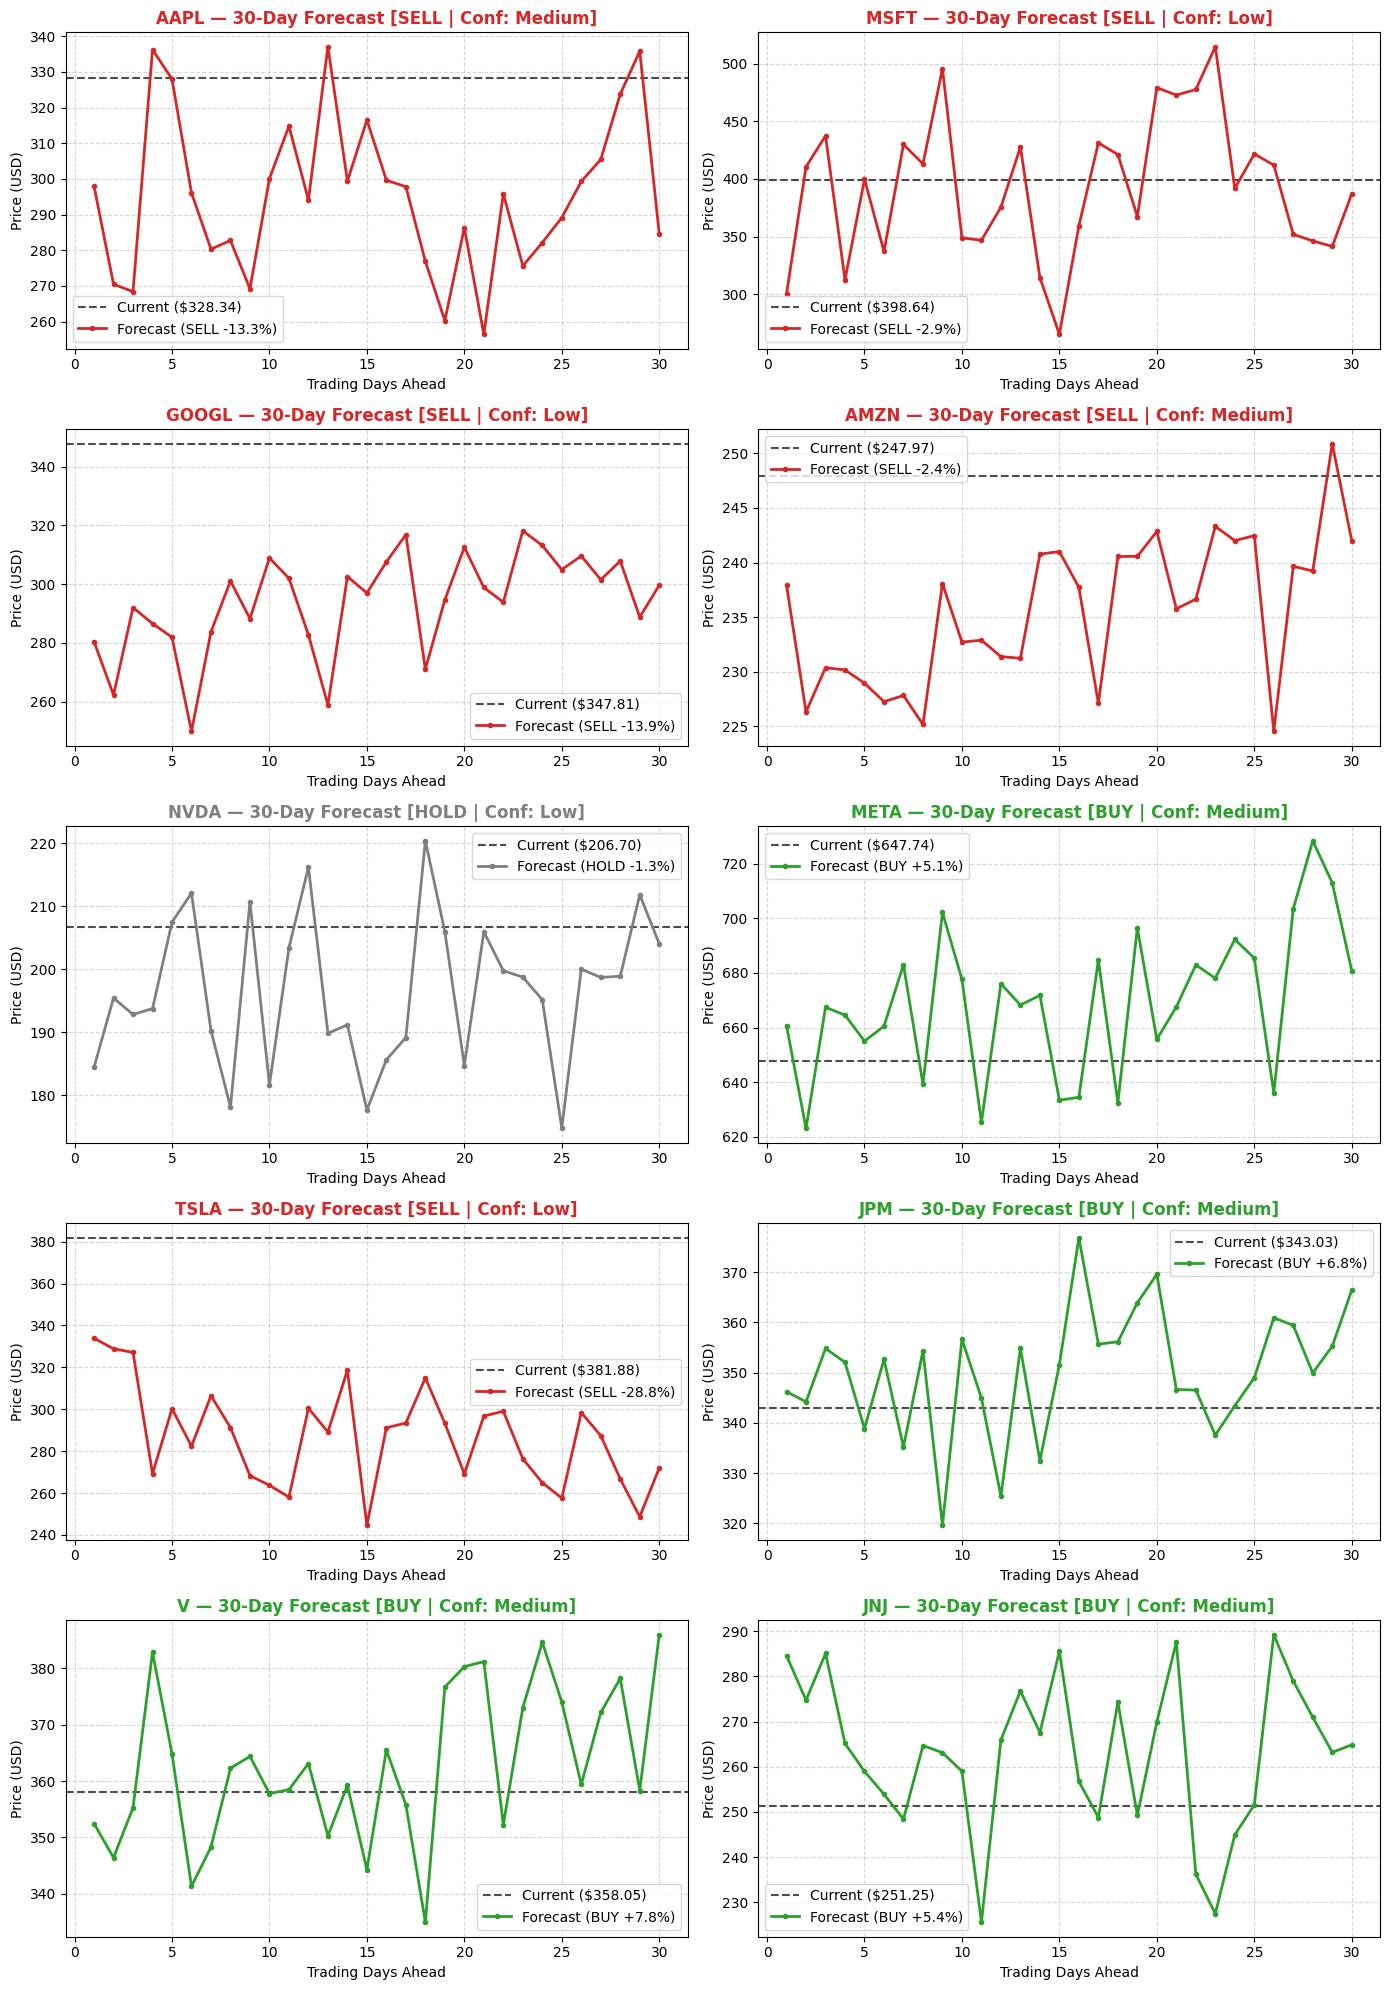

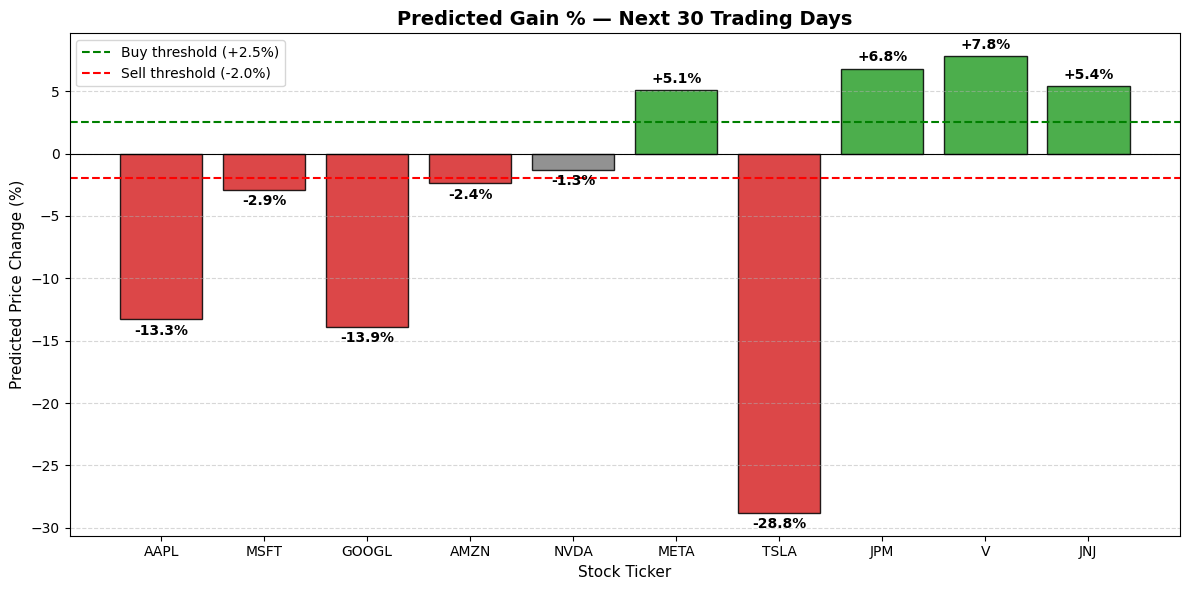

[✓] Recommendations successfully exported to 'stock_recommendations.csv'


In [16]:
n = len(rec_df)
cols = min(2, n)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).flatten()

for idx, row in rec_df.iterrows():
    ax = axes[idx]
    ticker = row['Stock']
    traj   = row['Trajectory']
    curr   = row['Current']
    signal = row['Signal']
    color = "#2ca02c" if signal == "BUY" else ("#d62728" if signal == "SELL" else "#7f7f7f")
    days  = np.arange(1, FORECAST_DAYS + 1)

    ax.axhline(curr, color="black", linestyle="--", alpha=0.7, label=f"Current (${curr:.2f})")
    ax.plot(days, traj, marker="o", markersize=3, color=color, linewidth=2, label=f"Forecast ({signal} {row['Gain%']:+.1f}%)")
    ax.set_title(f"{ticker} — 30-Day Forecast [{signal} | Conf: {row['Confidence']}]", fontsize=12, fontweight="bold", color=color)
    ax.set_xlabel("Trading Days Ahead")
    ax.set_ylabel("Price (USD)")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="best")

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#2ca02c" if s == "BUY" else ("#d62728" if s == "SELL" else "#7f7f7f") for s in rec_df['Signal']]
bars = ax.bar(rec_df['Stock'], rec_df['Gain%'], color=colors, edgecolor="black", alpha=0.85)
ax.axhline(BUY_THRESHOLD, color="green", linestyle="--", linewidth=1.5, label=f"Buy threshold (+{BUY_THRESHOLD:.1f}%)")
ax.axhline(SELL_THRESHOLD, color="red", linestyle="--", linewidth=1.5, label=f"Sell threshold ({SELL_THRESHOLD:.1f}%)")
ax.axhline(0, color="black", linewidth=0.8)
for bar, gain in zip(bars, rec_df['Gain%']):
    height = bar.get_height()
    va = "bottom" if height >= 0 else "top"
    ax.annotate(f"{gain:+.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -3),
                textcoords="offset points",
                ha='center', va=va, fontweight='bold', fontsize=10)
ax.set_title("Predicted Gain % — Next 30 Trading Days", fontsize=14, fontweight="bold")
ax.set_xlabel("Stock Ticker", fontsize=11)
ax.set_ylabel("Predicted Price Change (%)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5, axis="y")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

export_cols = [c for c in rec_df.columns if c != "Trajectory"]
rec_df[export_cols].to_csv("stock_recommendations.csv", index=False)
print("[✓] Recommendations successfully exported to 'stock_recommendations.csv'")